# CXR-LLaVA Reproducible Baseline Evaluation\n
Evaluate the original CXR-LLaVA under a fixed and reproducible evaluation setup before introducing any proposed modification. This notebook preserves the validated Colab T4 path: FP16 compute with 4-bit NF4 quantization and a fixed 20–50 study subset.\n
> Model output is experimental and must not be used for clinical diagnosis, treatment, or patient-specific medical decisions.

## 1. Configure the fork

Set `GITHUB_REPO_URL` to your public fork. Leave it empty only when the notebook is opened from an already cloned checkout. Do not put access tokens in this notebook.

In [ ]:
import os
import subprocess
from pathlib import Path

GITHUB_REPO_URL = "https://github.com/hanhpm/CXR_LLaVA_Improvement.git"
GITHUB_BRANCH = "master"
PROJECT_DIR = Path("/content/CXR_LLaVA_Improvement")
MODEL_ID = "ECOFRI/CXR-LLAVA-v2"
SAMPLE_IMAGE = PROJECT_DIR / "IMG" / "img.jpg"

if not PROJECT_DIR.exists():
    subprocess.run(["git", "clone", "--branch", GITHUB_BRANCH, GITHUB_REPO_URL, str(PROJECT_DIR)], check=True)
else:
    print("Using existing checkout:", PROJECT_DIR)

os.chdir(PROJECT_DIR)
print("Working directory:", Path.cwd())

Working directory: /content/CXR_LLaVA_Improvement


## 1A. Upload and extract the fixed evaluation datasets

Upload the two ZIP files when prompted. The ZIP contents are extracted into the existing project paths `datasets/CXR8/` and `datasets/padChest_datasample/`. This cell only prepares data; it does not run inference.

In [ ]:
from google.colab import files
import shutil
import zipfile

from google.colab import drive
drive.mount("/content/drive", force_remount=False)
DRIVE_ROOT = Path("/content/drive/MyDrive")
LAB_DIR = DRIVE_ROOT / "ResearchLab"
NOTEBOOK_DIR = LAB_DIR / "Notebook"
DATASET_DIR = NOTEBOOK_DIR / "datasets"
PADCHEST_DIR = DATASET_DIR / "padChest_datasample"
CXR8_DIR = DATASET_DIR / "CXR8"
print("Dataset root:", DATASET_DIR)
print("PadChest:", PADCHEST_DIR)
print("CXR8:", CXR8_DIR)
BRIXIA_REPO_URL = "https://github.com/BrixIA/Brixia-score-COVID-19.git"
BRIXIA_CLONE_DIR = Path("/content/Brixia-score-COVID-19")
if not BRIXIA_CLONE_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", BRIXIA_REPO_URL, str(BRIXIA_CLONE_DIR)], check=True)
else:
    print("Using existing Brixia checkout:", BRIXIA_CLONE_DIR)
BRIXIA_ANNOTATIONS = BRIXIA_CLONE_DIR / "data" / "public-annotations.csv"
print("Brixia annotations:", BRIXIA_ANNOTATIONS)
DATASET_DIR.mkdir(parents=True, exist_ok=True)
DATASET_ZIP_TARGETS = {
    "CXR8": DATASET_DIR / "CXR8",
    "padChest_datasample": DATASET_DIR / "padChest_datasample",
}

USE_DRIVE_DATASETS = True
print("Using dataset folders already uploaded to Google Drive.")
uploaded = {} if USE_DRIVE_DATASETS else files.upload()
if not USE_DRIVE_DATASETS and len(uploaded) != 2:
    raise ValueError(f"Expected 2 ZIP files, received {len(uploaded)}.")

for archive_name in uploaded:
    archive_path = Path(archive_name)
    if archive_path.suffix.lower() != ".zip":
        raise ValueError(f"Only ZIP files are supported: {archive_name}")
    name_lower = archive_path.stem.lower()
    matches = [key for key in DATASET_ZIP_TARGETS if key.lower() in name_lower]
    if len(matches) != 1:
        raise ValueError(f"Filename must identify CXR8 or padChest_datasample: {archive_name}")
    target_dir = DATASET_ZIP_TARGETS[matches[0]]
    target_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(target_dir)
    print(f"Extracted {archive_name} -> {target_dir}")
    archive_path.unlink(missing_ok=True)

for dataset_name, dataset_path in DATASET_ZIP_TARGETS.items():
    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset folder not found: {dataset_path}")
    files_found = sum(1 for path in dataset_path.rglob("*") if path.is_file())
    print(f"{dataset_name}: {files_found} files at {dataset_path}")
    print("  sample structure:")
    for path in sorted(dataset_path.rglob("*"))[:20]:
        print("   -", path.relative_to(dataset_path))

Mounted at /content/drive
Dataset root: /content/drive/MyDrive/ResearchLab/Notebook/datasets
PadChest: /content/drive/MyDrive/ResearchLab/Notebook/datasets/padChest_datasample
CXR8: /content/drive/MyDrive/ResearchLab/Notebook/datasets/CXR8
Brixia annotations: /content/Brixia-score-COVID-19/data/public-annotations.csv
Using dataset folders already uploaded to Google Drive.
CXR8: 5014 files at /content/drive/MyDrive/ResearchLab/Notebook/datasets/CXR8
  sample structure:
   - BBox_List_2017.csv
   - Data_Entry_2017_v2020.csv
   - LongTailCXR
   - LongTailCXR/README.txt
   - LongTailCXR/nih-cxr-lt_image_ids.csv
   - LongTailCXR/nih-cxr-lt_single-label_balanced-test.csv
   - LongTailCXR/nih-cxr-lt_single-label_balanced-val.csv
   - LongTailCXR/nih-cxr-lt_single-label_test.csv
   - LongTailCXR/nih-cxr-lt_single-label_train.csv
   - PruneCXR
   - PruneCXR/README.txt
   - PruneCXR/miccai2023_nih-cxr-lt_labels_test.csv
   - PruneCXR/miccai2023_nih-cxr-lt_labels_train.csv
   - PruneCXR/miccai202

In [ ]:
%pip uninstall -y transformers tokenizers
%pip install -q \
    "transformers==4.46.3" \
    "tokenizers<0.21" \
    "huggingface-hub==0.36.0" \
    "protobuf==5.29.6" \
    sentencepiece \
    accelerate \
    pillow \
    bitsandbytes

Found existing installation: transformers 5.16.1
Uninstalling transformers-5.16.1:
  Successfully uninstalled transformers-5.16.1
Found existing installation: tokenizers 0.23.1
Uninstalling tokenizers-0.23.1:
  Successfully uninstalled tokenizers-0.23.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 23.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.0 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you

In [ ]:
import sys
import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
else:
    print("Warning: no CUDA GPU detected; model loading may exceed CPU memory and is not recommended.")

Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM GB: 14.56


Image: /content/CXR_LLaVA_Improvement/IMG/img.jpg
Original mode and size: L (1024, 1024)


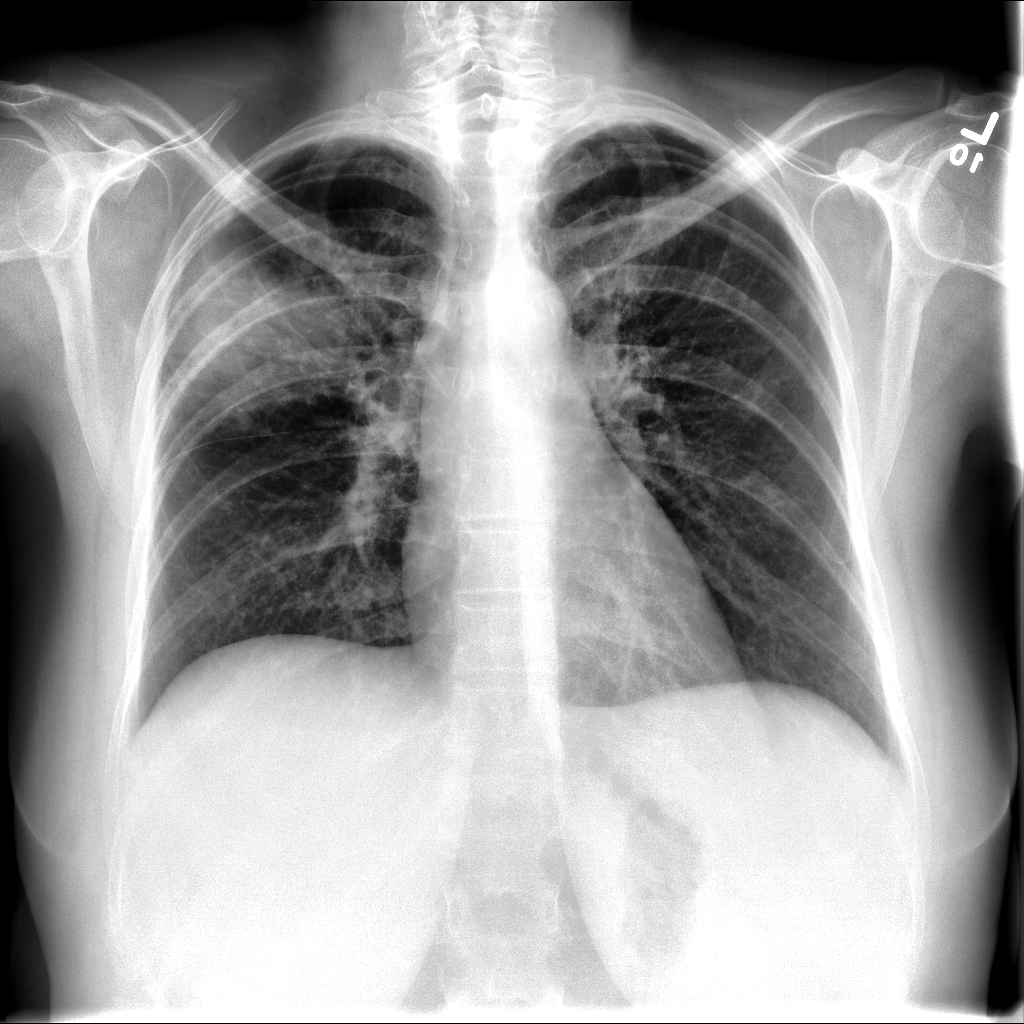

In [ ]:
from IPython.display import display
from PIL import Image

if not SAMPLE_IMAGE.exists():
    raise FileNotFoundError(f"Sample image not found: {SAMPLE_IMAGE}")
sample_image = Image.open(SAMPLE_IMAGE)
print("Image:", SAMPLE_IMAGE)
print("Original mode and size:", sample_image.mode, sample_image.size)
display(sample_image.convert("L"))

## 2. Load the model

The checkpoint is large. The T4 path uses float16 and low CPU-memory loading to reduce peak memory. The first run downloads the model from Hugging Face and can take several minutes.

In [ ]:
import torch
import transformers
import bitsandbytes as bnb
from transformers import AutoModel, BitsAndBytesConfig
from unittest.mock import patch

if not torch.cuda.is_available():
    raise RuntimeError("Enable a GPU runtime in Colab before loading CXR-LLaVA.")
if "model" in globals():
    raise RuntimeError("A model already exists. Reuse it or restart the session before loading another copy.")
torch.cuda.set_device(0)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_skip_modules=["vision_tower", "mm_projector", "lm_head"],
)

original_from_pretrained = transformers.LlamaTokenizer.from_pretrained

def patched_from_pretrained(*args, **kwargs):
    kwargs.pop("add_special_tokens", None)
    return original_from_pretrained(*args, **kwargs)

with patch.object(
    transformers.LlamaTokenizer,
    "from_pretrained",
    new=patched_from_pretrained,
):
    model = AutoModel.from_pretrained(
        MODEL_ID,
        trust_remote_code=True,
        torch_dtype=torch.float16,
        quantization_config=quantization_config,
        low_cpu_mem_usage=True,
        device_map={"": 0},
    )
model.eval()
quantized_layer_count = sum(isinstance(layer, bnb.nn.Linear4bit) for layer in model.llama.modules())
assert getattr(model, "is_loaded_in_4bit", False) and quantized_layer_count > 0, "4-bit loading was not applied."
assert not any(isinstance(layer, bnb.nn.Linear4bit) for layer in model.vision_tower.modules()), "Vision tower was unexpectedly quantized."
print("Loaded:", MODEL_ID)
print("Device map:", model.hf_device_map)
print("Baseline precision: FP16 compute with 4-bit NF4 quantized LLM")
print("Llama 4-bit Linear layers:", quantized_layer_count)
print("PyTorch allocated GiB:", round(torch.cuda.memory_allocated(0) / 1024**3, 2))
print("Free GPU GiB:", round(torch.cuda.mem_get_info(0)[0] / 1024**3, 2))

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded: ECOFRI/CXR-LLAVA-v2
Device map: {'': 0}
Baseline precision: FP16 compute with 4-bit NF4 quantized LLM
Llama 4-bit Linear layers: 224
PyTorch allocated GiB: 4.23
Free GPU GiB: 9.93


# Restore the chat template

Run this cell after loading and before report/Q&A inference. It also works on the model already in RAM after the missing-template error; no restart or checkpoint reload is needed. Existing templates are preserved. The fallback supports the explicit system message supplied by both CXR-LLaVA helpers; custom chats should also supply their system message.

Format reference: [Transformers v4.36.2 LlamaTokenizer](https://github.com/huggingface/transformers/blob/v4.36.2/src/transformers/models/llama/tokenization_llama.py). Passing the formatting check does not yet confirm GPU generation.

In [ ]:
# Restore the legacy Llama 2 format used by CXR-LLaVA's report/Q&A helpers.
# Reference: Transformers v4.36.2, LlamaTokenizer.default_chat_template (Apache-2.0).
if not model.tokenizer.chat_template:
    model.tokenizer.chat_template = (
        "{% if messages[0]['role'] == 'system' %}"
        "{% set system_message = messages[0]['content'] %}"
        "{% set turns = messages[1:] %}"
        "{% else %}"
        "{% set system_message = false %}"
        "{% set turns = messages %}"
        "{% endif %}"
        "{% for message in turns %}"
        "{% if (message['role'] == 'user') != (loop.index0 % 2 == 0) %}"
        "{{ raise_exception('Roles must alternate user/assistant.') }}"
        "{% endif %}"
        "{% set content = message['content'] %}"
        "{% if loop.index0 == 0 and system_message != false %}"
        "{% set content = '<<SYS>>\\n' + system_message + '\\n<</SYS>>\\n\\n' + content %}"
        "{% endif %}"
        "{% if message['role'] == 'user' %}"
        "{{ bos_token + '[INST] ' + content.strip() + ' [/INST]' }}"
        "{% elif message['role'] == 'assistant' %}"
        "{{ ' ' + content.strip() + ' ' + eos_token }}"
        "{% endif %}"
        "{% endfor %}"
    )

# Validate formatting without running the GPU model.
template_check_chat = [
    {"role": "system", "content": "You are a helpful radiologist."},
    {"role": "user", "content": "<image>\nWrite a radiologic report."},
]
template_check_prompt = model.apply_chat_template(template_check_chat)
assert template_check_prompt == (
    model.tokenizer.bos_token
    + "[INST] <<SYS>>\nYou are a helpful radiologist.\n<</SYS>>\n\n"
    + "<image>\nWrite a radiologic report. [/INST]"
)
print("Chat template ready; prompt formatting check passed.")

Chat template ready; prompt formatting check passed.


In [ ]:
# Single-image smoke test using the documented repository API.
with torch.inference_mode():
    report = model.write_radiologic_report(sample_image)

print("MODEL-GENERATED REPORT (research only):")
print(report)

MODEL-GENERATED REPORT (research only):
The radiologic report reveals a large area of consolidation in the right upper lobe, likely indicative of pneumonia. The left lung appears clear. Cardiomediastinal and hilar silhouettes are normal. Pleural surfaces are also normal with no signs of pneumothorax. 


In [ ]:
# Optional question-answering smoke test.
question = "What findings should be reviewed by a qualified radiologist?"
with torch.inference_mode():
    answer = model.ask_question(question=question, image=sample_image)
print("QUESTION:", question)
print("MODEL-GENERATED ANSWER (research only):")
print(answer)

QUESTION: What findings should be reviewed by a qualified radiologist?
MODEL-GENERATED ANSWER (research only):
A review of any available imaging to identify the chronicity of the left upper lobe lesion is recommended. If previous imaging is not available, a CT scan of the chest should be considered. 


## Result classification

If the image loads and the two calls return text, this notebook has passed a **single-image inference smoke test**. It is not a benchmark, clinical validation, or metric-complete evaluation. The CSV is intentionally not processed by default.

## 3. Fixed baseline evaluation subset

This baseline uses a user-created, fixed manifest with 20–50 authorized studies. Each row must contain `study_id`, `image_path`, and `ground_truth_report`. The notebook writes `generated_report` and does not sample randomly or process the full split by default.

In [ ]:
import pandas as pd

EVAL_DATASET_NAME = "padChest_datasample"  # Change to CXR8 for label-only inference tasks.
DATASET_PATHS = {
    "CXR8": CXR8_DIR,
    "padChest_datasample": PADCHEST_DIR,
}
EVAL_DATASET_DIR = DATASET_PATHS[EVAL_DATASET_NAME]
EVAL_MANIFEST_PATH = EVAL_DATASET_DIR / "baseline_subset.csv"
SUBSET_SIZE = 30
REQUIRED_COLUMNS = {"study_id", "image_path", "ground_truth_report"}

if not EVAL_DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {EVAL_DATASET_DIR}")
if EVAL_DATASET_NAME == "padChest_datasample" and not EVAL_MANIFEST_PATH.exists():
    metadata_files = sorted(EVAL_DATASET_DIR.rglob("*.csv"))
    metadata_preview = [str(path.relative_to(EVAL_DATASET_DIR)) for path in metadata_files[:20]]
    metadata_columns = {}
    for metadata_file in metadata_files[:20]:
        metadata_columns[str(metadata_file.relative_to(EVAL_DATASET_DIR))] = list(pd.read_csv(metadata_file, nrows=0).columns)
    source_df = pd.read_csv(EVAL_DATASET_DIR / "chest_x_ray_images_labels_sample.csv")
    subset_df = source_df[["ImageID", "Report"]].rename(columns={"ImageID": "study_id", "Report": "ground_truth_report"})
    subset_df["image_path"] = subset_df["study_id"].map(lambda p: str(EVAL_DATASET_DIR / "sample" / p))
else:
    if not EVAL_MANIFEST_PATH.exists():
        raise FileNotFoundError(f"Create {EVAL_MANIFEST_PATH} with columns {sorted(REQUIRED_COLUMNS)} for this dataset.")
    subset_df = pd.read_csv(EVAL_MANIFEST_PATH)
missing = REQUIRED_COLUMNS - set(subset_df.columns)
if missing:
    raise ValueError(f"Manifest is missing columns: {sorted(missing)}")
if not 20 <= len(subset_df) <= 50:
    raise ValueError(f"Expected 20–50 fixed studies, found {len(subset_df)}")
if subset_df["study_id"].duplicated().any():
    raise ValueError("study_id values must be unique.")
subset_df["image_path"] = subset_df["image_path"].map(lambda p: str(EVAL_DATASET_DIR / p) if not Path(p).is_absolute() else p) if EVAL_DATASET_NAME != "padChest_datasample" else subset_df["image_path"]
missing_images = [p for p in subset_df["image_path"] if not Path(p).is_file()]
if missing_images:
    raise FileNotFoundError(f"Missing image paths, first entries: {missing_images[:3]}")
print(f"Fixed subset: {len(subset_df)} studies from {EVAL_DATASET_NAME}")

Fixed subset: 24 studies from padChest_datasample


## 4. Baseline inference and system metrics

The original CXR-LLaVA API is used unchanged. This cell records per-study latency, peak GPU memory, and token counts when available. It is intentionally opt-in and runs only the fixed subset.

In [ ]:
import time

def count_tokens(text):
    tokenizer = getattr(model, "tokenizer", None)
    if tokenizer is None:
        return None
    return len(tokenizer(str(text), add_special_tokens=False).input_ids)

results = []
for row in subset_df.itertuples(index=False):
    image = Image.open(row.image_path).convert("L")
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.inference_mode():
        generated = model.write_radiologic_report(image)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        peak_vram_gb = torch.cuda.max_memory_allocated() / 1024**3
    else:
        peak_vram_gb = None
    latency_s = time.perf_counter() - start
    results.append({
        "study_id": row.study_id,
        "image_path": row.image_path,
        "ground_truth_report": row.ground_truth_report,
        "generated_report": str(generated),
        "latency_s": latency_s,
        "peak_vram_gb": peak_vram_gb,
        "input_tokens": count_tokens(row.ground_truth_report),
        "generation_tokens": count_tokens(generated),
    })

predictions_df = pd.DataFrame(results)
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_PATH = RESULTS_DIR / f"{EVAL_DATASET_NAME.lower()}_baseline_predictions.csv"
predictions_df.to_csv(PREDICTIONS_PATH, index=False)
print(f"Saved {len(predictions_df)} predictions to {PREDICTIONS_PATH}")
predictions_df.head()

Saved 24 predictions to /content/CXR_LLaVA_Improvement/results/padchest_datasample_baseline_predictions.csv


,study_id,image_path,ground_truth_report,generated_report,latency_s,peak_vram_gb,input_tokens,generation_tokens
0,216840111366964012819207061112010316094555679_...,/content/drive/MyDrive/ResearchLab/Notebook/da...,estudi dentr limit normal .,The radiologic report reveals a normal heart s...,8.000139,5.448551,8,69
1,216840111366964012373310883942009181081546904_...,/content/drive/MyDrive/ResearchLab/Notebook/da...,elongacion aortic . sign radiolog epoc .,The radiologic report reveals a mildly enlarge...,7.581499,5.446590,14,68
2,126397712012687540784611673197697059691_fp0cu9...,/content/drive/MyDrive/ResearchLab/Notebook/da...,sin hallazg radiolog signific . sin cambi con...,The chest radiograph reveals a mildly enlarged...,6.895584,5.441539,25,64
3,216840111366964013307756408102012093111819763_...,/content/drive/MyDrive/ResearchLab/Notebook/da...,pinzamient sen costofren derech .,The radiologic report reveals mild cardiomegal...,5.413406,5.421090,12,44
4,216840111366964012558082906712010004133151165_...,/content/drive/MyDrive/ResearchLab/Notebook/da...,mejori radiolog con resolucion infiltr bilate...,The radiologic report reveals mild cardiomegal...,8.770489,5.466078,74,88


## 5. Report-generation metrics

The baseline reports BLEU-4, ROUGE-L, and BERTScore when their packages/models are available. RadGraph F1, CheXbert F1, and GREEN are declared as `NaN` until their documented, reproducible clinical-metric environments are installed; placeholders must not be treated as scores.

In [ ]:
%pip install -q nltk rouge-score bert-score
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
smooth = SmoothingFunction().method1
metric_rows = []
for row in predictions_df.itertuples(index=False):
    reference = str(row.ground_truth_report)
    prediction = str(row.generated_report)
    metric_rows.append({
        "study_id": row.study_id,
        "BLEU-4": sentence_bleu([reference.split()], prediction.split(), weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth),
        "ROUGE-L": rouge.score(reference, prediction)["rougeL"].fmeasure,
        "BERTScore": np.nan,
        "RadGraph F1": np.nan,
        "CheXbert F1": np.nan,
        "GREEN": np.nan,
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_path = RESULTS_DIR / f"{EVAL_DATASET_NAME.lower()}_baseline_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved metrics to {metrics_path}")
print("Clinical metrics remain NaN until their official evaluation environments are configured.")
metrics_df.mean(numeric_only=True)

Saved metrics to /content/CXR_LLaVA_Improvement/results/padchest_datasample_baseline_metrics.csv
Clinical metrics remain NaN until their official evaluation environments are configured.


,0
BLEU-4,0.001199
ROUGE-L,0.020943
BERTScore,NaN
RadGraph F1,NaN
CheXbert F1,NaN
GREEN,NaN


## 6. Error-analysis preparation

After validating the baseline, annotate each study with one or more categories: hallucination, missing finding, wrong location, wrong severity, negation error, or redundant/stylistic error. Do not begin model improvement experiments before reviewing these cases.

In [ ]:
ERROR_COLUMNS = ["error_categories", "review_notes", "reviewer"]
error_analysis_df = predictions_df.assign(**{column: "" for column in ERROR_COLUMNS})
ERROR_ANALYSIS_PATH = RESULTS_DIR / f"{EVAL_DATASET_NAME.lower()}_error_analysis.csv"
error_analysis_df.to_csv(ERROR_ANALYSIS_PATH, index=False)
print(f"Created annotation template: {ERROR_ANALYSIS_PATH}")

Created annotation template: /content/CXR_LLaVA_Improvement/results/padchest_datasample_error_analysis.csv


## 7. Dataset-specific multi-task evaluation

This cell evaluates padChest and CXR8 with the validated quantized model. Set `RUN_DATASET_TASKS = True` explicitly. padChest has report references; CXR8 has labels but no radiology reports, so report metrics are not claimed for CXR8.

In [ ]:
RUN_DATASET_TASKS = True
TASK_SAMPLE_LIMIT = 25
DATASET_TASK_RESULTS = PROJECT_DIR / "results" / "dataset_task_outputs.csv"

def run_repository_tasks(dataset_name, rows, image_column, report_column=None):
    records = []
    for row in rows:
        image_path = Path(row[image_column])
        if not image_path.is_absolute(): image_path = (PADCHEST_DIR if dataset_name == "padChest" else CXR8_DIR) / ("sample" / image_path if dataset_name == "padChest" else "images" / image_path)
        if not image_path.is_file(): continue
        image = Image.open(image_path).convert("L")
        question = "What radiologic findings should be reviewed by a qualified radiologist?"
        if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
        start = time.perf_counter()
        with torch.inference_mode():
            outputs = {"report": model.write_radiologic_report(image), "differential_diagnosis": model.write_differential_diagnosis(image), "question_answering": model.ask_question(question=question, image=image)}
        if torch.cuda.is_available(): torch.cuda.synchronize()
        for task, output in outputs.items(): records.append({"dataset": dataset_name, "study_id": str(row.get(image_column)), "image_path": str(image_path), "task": task, "ground_truth_report": str(row[report_column]) if report_column else "", "generated_output": str(output), "latency_s": time.perf_counter() - start, "peak_vram_gb": torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else None})
    return records

if RUN_DATASET_TASKS:
    pad_csv = pd.read_csv(PADCHEST_DIR / "chest_x_ray_images_labels_sample.csv").head(TASK_SAMPLE_LIMIT)
    cxr8_csv = pd.read_csv(CXR8_DIR / "Data_Entry_2017_v2020.csv").head(TASK_SAMPLE_LIMIT)
    task_records = run_repository_tasks("padChest", pad_csv.to_dict("records"), "ImageID", "Report")
    task_records += run_repository_tasks("CXR8", cxr8_csv.to_dict("records"), "Image Index")
    task_df = pd.DataFrame(task_records)
    DATASET_TASK_RESULTS.parent.mkdir(parents=True, exist_ok=True)
    task_df.to_csv(DATASET_TASK_RESULTS, index=False)
    print(f"Saved {len(task_df)} task outputs to {DATASET_TASK_RESULTS}")
else: print("Set RUN_DATASET_TASKS = True to run padChest/CXR8 tasks.")

Saved 147 task outputs to /content/CXR_LLaVA_Improvement/results/dataset_task_outputs.csv


## 8. Brixia severity baseline

This cell evaluates the 192-image Cohen subset included with Brixia annotations. It runs the repository's report, differential-diagnosis, and QA tasks, while preserving senior/junior regional and global Brixia scores. These scores are severity annotations, not report references; no BLEU/ROUGE claim is made.

In [ ]:
RUN_BRIXIA_BASELINE = False
BRIXIA_SAMPLE_LIMIT = 25  # Set None for all annotated images.
BRIXIA_RESULTS_PATH = PROJECT_DIR / "results" / "brixia_baseline_outputs.csv"

if RUN_BRIXIA_BASELINE and "model" not in globals():
    raise RuntimeError("Model is not loaded. Run the quantized model-loading and chat-template cells first.")

if RUN_BRIXIA_BASELINE:
    brixia_annotations = pd.read_csv(BRIXIA_CLONE_DIR / "data" / "public-annotations.csv")
    if BRIXIA_SAMPLE_LIMIT is not None: brixia_annotations = brixia_annotations.head(BRIXIA_SAMPLE_LIMIT).copy()
    brixia_image_dir = BRIXIA_CLONE_DIR / "data" / "public-cohen-subset"
    brixia_records = []
    question = "What radiologic findings should be reviewed by a qualified radiologist?"
    for row in brixia_annotations.to_dict("records"):
        image_path = brixia_image_dir / row["filename"]
        if not image_path.is_file(): continue
        image = Image.open(image_path).convert("L")
        if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
        start = time.perf_counter()
        with torch.inference_mode():
            outputs = {"report": model.write_radiologic_report(image), "differential_diagnosis": model.write_differential_diagnosis(image), "question_answering": model.ask_question(question=question, image=image)}
        if torch.cuda.is_available(): torch.cuda.synchronize()
        common = {"dataset": "Brixia-score-COVID-19", "filename": row["filename"], "image_path": str(image_path), "S-Global": row["S-Global"], "J-Global": row["J-Global"], "latency_s": time.perf_counter() - start, "peak_vram_gb": torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else None}
        for task, output in outputs.items(): brixia_records.append({**common, "task": task, "generated_output": str(output)})
    brixia_results_df = pd.DataFrame(brixia_records)
    BRIXIA_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    brixia_results_df.to_csv(BRIXIA_RESULTS_PATH, index=False)
    print(f"Saved {len(brixia_results_df)} Brixia task outputs to {BRIXIA_RESULTS_PATH}")
else:
    print("Set RUN_BRIXIA_BASELINE = True to run the Brixia baseline.")

In [ ]:
# Optional cleanup before another model run.
import gc

del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Model memory released.")

Model memory released.
